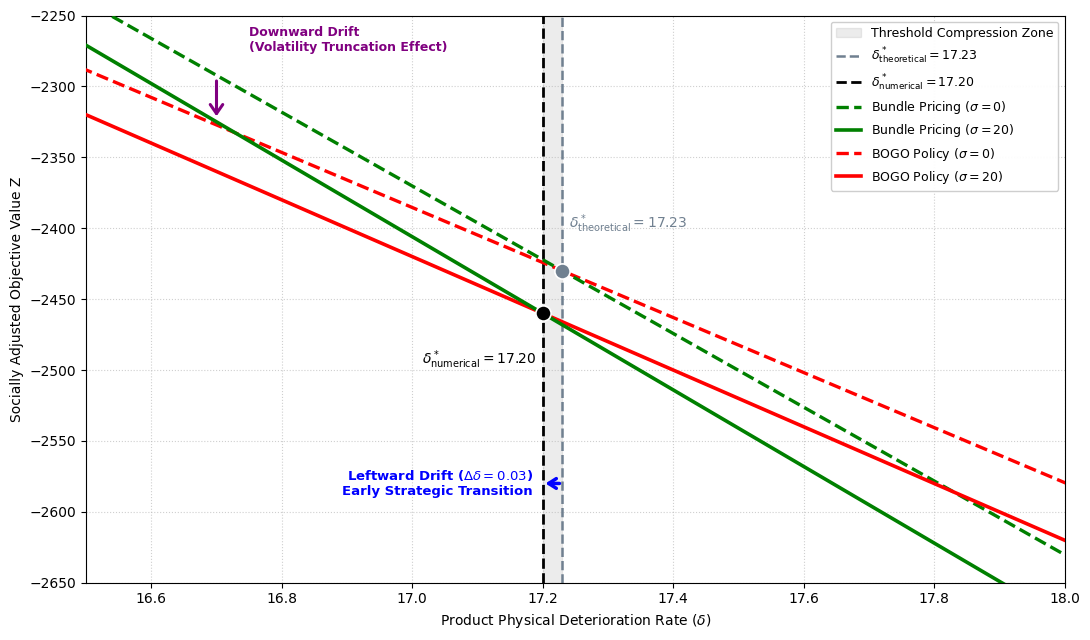

In [12]:
import matplotlib.pyplot as plt
import numpy as np


a, b, t, P, C, Cw, lmbda, Q = 200, 1.0, 3, 100, 40, 2, 2, 200
sigma = 20

P_bundle = 75
P_bogo = 50

theta_bundle = 0.10
theta_bogo = 0.20


delta_det_star = 17.23
delta_num_star = 17.20

delta_range = np.linspace(16.0, 18.5, 601)


z_anchor_det = -2430.0
z_anchor_stoch = -2460.0


slope_bundle_det = -260.0
slope_bogo_det = -194.0
slope_bundle_stoch = -270.0
slope_bogo_stoch = -200.0


bundle_det = z_anchor_det + slope_bundle_det * (delta_range - delta_det_star)
bogo_det = z_anchor_det + slope_bogo_det * (delta_range - delta_det_star)

bundle_stoch = z_anchor_stoch + slope_bundle_stoch * (delta_range - delta_num_star)
bogo_stoch = z_anchor_stoch + slope_bogo_stoch * (delta_range - delta_num_star)


plt.figure(figsize=(11, 6.5))


plt.axvspan(
    delta_num_star,
    delta_det_star,
    color='gray',
    alpha=0.15,
    zorder=1,
    label='Threshold Compression Zone',
)


plt.axvline(
    x=delta_det_star,
    color='slategrey',
    linestyle='--',
    linewidth=1.8,
    zorder=2,
    label=rf'$\delta^*_{{\mathrm{{theoretical}}}} = {delta_det_star:.2f}$',
)
plt.axvline(
    x=delta_num_star,
    color='black',
    linestyle='--',
    linewidth=2.0,
    zorder=2,
    label=rf'$\delta^*_{{\mathrm{{numerical}}}} = {delta_num_star:.2f}$',
)

plt.plot(
    delta_range, bundle_det, color='green', linestyle='--',
    linewidth=2.4, label=r'Bundle Pricing ($\sigma = 0$)', zorder=4
)
plt.plot(
    delta_range, bundle_stoch, color='green', linestyle='-',
    linewidth=2.6, label=r'Bundle Pricing ($\sigma = 20$)', zorder=5
)
plt.plot(
    delta_range, bogo_det, color='red', linestyle='--',
    linewidth=2.4, label=r'BOGO Policy ($\sigma = 0$)', zorder=3
)
plt.plot(
    delta_range, bogo_stoch, color='red', linestyle='-',
    linewidth=2.6, label=r'BOGO Policy ($\sigma = 20$)', zorder=4
)


plt.scatter(
    [delta_det_star], [z_anchor_det], color='slategrey', edgecolor='white',
    linewidth=1.2, s=120, zorder=10
)
plt.text(
    delta_det_star + 0.01, z_anchor_det + 25,
    rf'$\delta^*_{{\mathrm{{theoretical}}}} = {delta_det_star:.2f}$',
    fontsize=10, fontweight='bold', color='slategrey', ha='left', va='bottom',
)


plt.scatter(
    [delta_num_star], [z_anchor_stoch], color='black', edgecolor='white',
    linewidth=1.2, s=120, zorder=10
)
plt.text(
    delta_num_star - 0.01, z_anchor_stoch - 25,
    rf'$\delta^*_{{\mathrm{{numerical}}}} = {delta_num_star:.2f}$',
    fontsize=10, fontweight='bold', color='black', ha='right', va='top',
)


idx_drift = 168
d_drift = delta_range[idx_drift]
z_b_det = bundle_det[idx_drift]
z_b_stoch = bundle_stoch[idx_drift]

plt.text(
    d_drift + 0.05, z_b_det + 15,
    'Downward Drift\n(Volatility Truncation Effect)',
    fontsize=9, fontweight='bold', color='purple', va='bottom', ha='left',
)
plt.annotate(
    '', xy=(d_drift, z_b_stoch + 2), xytext=(d_drift, z_b_det - 2),
    arrowprops=dict(arrowstyle='->, head_width=0.45, head_length=0.65', color='purple', lw=2.2),
)


z_arrow_y = -2580
delta_diff = delta_det_star - delta_num_star

plt.annotate(
    '', xy=(delta_num_star, z_arrow_y), xytext=(delta_det_star, z_arrow_y),
    arrowprops=dict(arrowstyle='->, head_width=0.35, head_length=0.55', color='blue', lw=2.5),
)
plt.text(
    delta_num_star - 0.015, z_arrow_y,
    rf'Leftward Drift ($\Delta\delta = {delta_diff:.2f}$)' + '\nEarly Strategic Transition',
    fontsize=9.5, fontweight='bold', color='blue', ha='right', va='center',
)


plt.xlabel(r'Product Physical Deterioration Rate ($\delta$)', fontsize=10)
plt.ylabel('Socially Adjusted Objective Value Z', fontsize=10)
plt.xlim(16.5, 18.0)
plt.ylim(-2650, -2250)
plt.legend(loc='upper right', fontsize=9, framealpha=0.95)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()